# ECGR 4106/5106 — Homework 5
Vision Transformers on CIFAR-100. Problem 1: ViT from scratch (5 configs) vs ResNet-18. Problem 2: Swin-Tiny/Small fine-tuning vs a Swin trained from scratch.
Seed 42, 45k/5k/10k split, Adam.

In [ ]:
!pip -q install fvcore transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os, json, time, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No gpu')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
if 'SAVE_DIR' not in globals():
    SAVE_DIR = './hw5_results'
os.makedirs(SAVE_DIR, exist_ok=True)
print('saved to:', SAVE_DIR)

saved to: ./hw5_results


## Data — Problem 1 (32x32)
45k train / 5k val / 10k test. Crop + flip on train only. Batch size 64.

In [ ]:
 # ==========================
# Download CIFAR-100 (Google Colab)
# ==========================

import os
import shutil
from torchvision.datasets import CIFAR100

# Remove any corrupted download
if os.path.exists("./data"):
    shutil.rmtree("./data")

os.makedirs("./data", exist_ok=True)

print("Downloading CIFAR-100...")

train_dataset = CIFAR100(
    root="./data",
    train=True,
    download=True
)

test_dataset = CIFAR100(
    root="./data",
    train=False,
    download=True
)

print("\n✅ Download completed successfully!")
print(f"Training images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Class names:\n{train_dataset.classes}")

100%|██████████| 169M/169M [50:14<00:00, 56.1kB/s]



✅ Download completed successfully!
Training images: 50000
Test images: 10000
Number of classes: 100
Class names:
['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'tele

In [ ]:
CIFAR_MEAN = (0.5071, 0.4865, 0.4409)
CIFAR_STD  = (0.2673, 0.2564, 0.2762)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
eval_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

root = './data'
full_train_aug  = torchvision.datasets.CIFAR100(root, train=True,  download=True, transform=train_tf)
full_train_eval = torchvision.datasets.CIFAR100(root, train=True,  download=True, transform=eval_tf)
test_set        = torchvision.datasets.CIFAR100(root, train=False, download=True, transform=eval_tf)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(50_000, generator=g).tolist()
train_idx, val_idx = perm[:45_000], perm[45_000:]

train_set = Subset(full_train_aug,  train_idx)
val_set   = Subset(full_train_eval, val_idx)

train_loader = DataLoader(train_set, batch_size=64,  shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
P1_LOADERS = (train_loader, val_loader, test_loader)

CLASSES = full_train_aug.classes
print(f'train {len(train_set)} | val {len(val_set)} | test {len(test_set)} | {len(CLASSES)} classes')

train 45000 | val 5000 | test 10000 | 100 classes


## Training and profiling utilities

In [ ]:
if 'RESULTS' not in globals():
    RESULTS = {}

def slug(s):                                  # config names have '/' in them, keep them out of paths
    return ''.join(c if c.isalnum() or c in '._-' else '_' for c in s)

def total_params(m):     return sum(p.numel() for p in m.parameters())
def trainable_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

def gflops(model, input_size):
    model.eval()
    try:
        from fvcore.nn import FlopCountAnalysis
        fa = FlopCountAnalysis(model, torch.zeros(1, *input_size, device=device))
        fa.unsupported_ops_warnings(False)
        fa.uncalled_modules_warnings(False)
        return 2 * fa.total() / 1e9
    except Exception as e:
        print('FLOP count failed:', e)
        return float('nan')

def save_run(name, model=None):
    RESULTS[name]['name'] = name
    with open(os.path.join(SAVE_DIR, f'{slug(name)}.json'), 'w') as f:
        json.dump(RESULTS[name], f)
    if model is not None:
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'{slug(name)}.pt'))

def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return loss_sum / n, correct / n

def train_model(model, name, loaders, epochs=10, lr=1e-3):
    if name in RESULTS:
        print(f'[{name}] already completed — skipping (delete from RESULTS to retrain).')
        return None
    train_loader, val_loader, test_loader = loaders
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    input_size = tuple(next(iter(train_loader))[0].shape[1:])
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}
    for epoch in range(epochs):
        model.train()
        t0, running, n = time.time(), 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
            n += x.size(0)
        train_loss = running / n
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        dt = time.time() - t0
        for k, v in zip(history, (train_loss, val_loss, val_acc, dt)):
            history[k].append(v)
        print(f'[{name}] epoch {epoch+1:2d}/{epochs} | train {train_loss:.4f} | '
              f'val {val_loss:.4f} | val acc {val_acc*100:.2f}% | {dt:.1f}s')

    _, test_acc = evaluate(model, test_loader, criterion)
    RESULTS[name] = {
        'history': history,
        'test_acc': test_acc,
        'params': total_params(model),
        'trainable': trainable_params(model),
        'gflops': gflops(model, input_size),
        'avg_epoch_time': float(np.mean(history['epoch_time'])),
        'total_time': float(np.sum(history['epoch_time'])),
    }
    save_run(name, model)
    print(f'[{name}] DONE — test {test_acc*100:.2f}% | {total_params(model):,} params | '
          f'{RESULTS[name]["gflops"]:.2f} GFLOPs | {RESULTS[name]["avg_epoch_time"]:.1f}s/epoch')
    return model

def reload_results():
    for fn in sorted(os.listdir(SAVE_DIR)):
        if fn.endswith('.json'):
            with open(os.path.join(SAVE_DIR, fn)) as f:
                r = json.load(f)
            RESULTS[r.get('name', fn[:-5])] = r
    print('Restored:', list(RESULTS.keys()))

def plot_history(names, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for name in names:
        h = RESULTS[name]['history']
        ep = range(1, len(h['train_loss']) + 1)
        axes[0].plot(ep, h['train_loss'], label=name)
        axes[1].plot(ep, h['val_loss'], label=name)
        axes[2].plot(ep, [a * 100 for a in h['val_acc']], label=name)
    for ax, ylab in zip(axes, ['Training loss', 'Validation loss', 'Validation accuracy (%)']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylab); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

def results_table(names):
    rows = []
    for n in names:
        r = RESULTS[n]
        rows.append({'model': n,
                     'params': f"{r['params']:,}",
                     'trainable': f"{r['trainable']:,}",
                     'GFLOPs': round(r['gflops'], 3),
                     'test acc (%)': round(r['test_acc'] * 100, 2),
                     'best val acc (%)': round(max(r['history']['val_acc']) * 100, 2),
                     's/epoch': round(r['avg_epoch_time'], 1)})
    return pd.DataFrame(rows)

---
# Problem 1 — ViT from scratch vs ResNet-18

In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, emb_dim=256):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=patch_size, stride=patch_size)  # patch split + linear proj in one conv

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)   # B,C,H,W -> B,N,D

class EncoderBlock(nn.Module):
    def __init__(self, emb_dim, n_heads, mlp_dim, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_dim)
        self.attn  = nn.MultiheadAttention(emb_dim, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, emb_dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        h = self.norm1(x)                             # pre-norm
        x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, num_classes=100,
                 emb_dim=256, depth=4, n_heads=4, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, emb_dim)
        n = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, emb_dim))
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[
            EncoderBlock(emb_dim, n_heads, emb_dim * mlp_ratio, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed   # prepend class token
        x = self.drop(x)
        x = self.blocks(x)
        return self.head(self.norm(x)[:, 0])              # classify off the class token

In [ ]:
VIT_CONFIGS = {
    'ViT-base (p4/d256/L4/h4)': dict(patch_size=4, emb_dim=256, depth=4, n_heads=4),
    'ViT-p8 (p8/d256/L4/h4)':   dict(patch_size=8, emb_dim=256, depth=4, n_heads=4),
    'ViT-d512 (p4/d512/L4/h4)': dict(patch_size=4, emb_dim=512, depth=4, n_heads=4),
    'ViT-L8 (p4/d256/L8/h4)':   dict(patch_size=4, emb_dim=256, depth=8, n_heads=4),
    'ViT-h8 (p4/d256/L4/h8)':   dict(patch_size=4, emb_dim=256, depth=4, n_heads=8),
}

rows = []
for name, cfg in VIT_CONFIGS.items():
    m = ViT(**cfg).to(device)
    rows.append({'config': name, 'patches': m.patch_embed.n_patches,
                 'params': f'{total_params(m):,}', 'GFLOPs': round(gflops(m, (3, 32, 32)), 3)})
print(pd.DataFrame(rows).to_string(index=False))

                  config  patches     params  GFLOPs
ViT-base (p4/d256/L4/h4)       64  3,214,692   0.412
  ViT-p8 (p8/d256/L4/h4)       16  3,239,268   0.109
ViT-d512 (p4/d512/L4/h4)       64 12,720,740   1.642
  ViT-L8 (p4/d256/L8/h4)       64  6,373,732   0.822
  ViT-h8 (p4/d256/L4/h8)       64  3,214,692   0.412


In [ ]:
for name, cfg in VIT_CONFIGS.items():
    train_model(ViT(**cfg), name, P1_LOADERS, epochs=10, lr=1e-3)

[ViT-base (p4/d256/L4/h4)] already completed — skipping (delete from RESULTS to retrain).
[ViT-p8 (p8/d256/L4/h4)] already completed — skipping (delete from RESULTS to retrain).
[ViT-d512 (p4/d512/L4/h4)] epoch  1/10 | train 4.2387 | val 4.0529 | val acc 7.28% | 19.1s
[ViT-d512 (p4/d512/L4/h4)] epoch  2/10 | train 4.1715 | val 4.1445 | val acc 6.18% | 19.1s
[ViT-d512 (p4/d512/L4/h4)] epoch  3/10 | train 4.1059 | val 4.1362 | val acc 6.10% | 19.2s
[ViT-d512 (p4/d512/L4/h4)] epoch  4/10 | train 4.1082 | val 4.0338 | val acc 7.48% | 19.0s
[ViT-d512 (p4/d512/L4/h4)] epoch  5/10 | train 4.1060 | val 4.0954 | val acc 7.48% | 19.0s
[ViT-d512 (p4/d512/L4/h4)] epoch  6/10 | train 4.0506 | val 4.0470 | val acc 7.58% | 19.0s
[ViT-d512 (p4/d512/L4/h4)] epoch  7/10 | train 4.1780 | val 4.1331 | val acc 5.88% | 19.1s
[ViT-d512 (p4/d512/L4/h4)] epoch  8/10 | train 4.1218 | val 4.0705 | val acc 7.24% | 19.1s
[ViT-d512 (p4/d512/L4/h4)] epoch  9/10 | train 4.0942 | val 4.0450 | val acc 7.64% | 18.9s
[Vi

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:        # downsampling shortcut (1x1 conv + BN)
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))     # the skip connection

class ResNetCifar(nn.Module):
    def __init__(self, blocks_per_stage, num_classes=100):
        super().__init__()
        self.stem = nn.Sequential(                # CIFAR stem: 3x3 conv, stride 1, NO max pool
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        stages, in_ch = [], 64
        for i, (ch, n_blocks) in enumerate(zip([64, 128, 256, 512], blocks_per_stage)):
            for j in range(n_blocks):
                stride = 2 if (i > 0 and j == 0) else 1
                stages.append(BasicBlock(in_ch, ch, stride))
                in_ch = ch
        self.stages = nn.Sequential(*stages)
        self.pool   = nn.AdaptiveAvgPool2d(1)     # global average pooling
        self.fc     = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(x).flatten(1)
        return self.fc(x)

def resnet18_cifar(): return ResNetCifar([2, 2, 2, 2])

print(f'ResNet-18 params: {total_params(resnet18_cifar()):,}')

ResNet-18 params: 11,220,132


In [ ]:
train_model(resnet18_cifar(), 'ResNet-18', P1_LOADERS, epochs=10, lr=1e-3)

[ResNet-18] epoch  1/10 | train 3.9137 | val 3.6300 | val acc 14.04% | 10.4s
[ResNet-18] epoch  2/10 | train 3.2644 | val 3.0196 | val acc 24.64% | 9.8s
[ResNet-18] epoch  3/10 | train 2.7451 | val 2.6684 | val acc 30.88% | 9.8s
[ResNet-18] epoch  4/10 | train 2.3562 | val 2.3386 | val acc 37.92% | 9.8s
[ResNet-18] epoch  5/10 | train 2.0776 | val 2.0501 | val acc 45.22% | 9.7s
[ResNet-18] epoch  6/10 | train 1.8547 | val 1.9220 | val acc 47.42% | 9.7s
[ResNet-18] epoch  7/10 | train 1.6693 | val 1.8348 | val acc 50.22% | 9.9s
[ResNet-18] epoch  8/10 | train 1.5175 | val 1.7561 | val acc 52.86% | 10.0s
[ResNet-18] epoch  9/10 | train 1.3716 | val 1.5807 | val acc 56.38% | 9.8s
[ResNet-18] epoch 10/10 | train 1.2538 | val 1.5936 | val acc 57.02% | 9.7s
[ResNet-18] DONE — test 57.36% | 11,220,132 params | 1.11 GFLOPs | 9.9s/epoch


ResNetCifar(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stages): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    

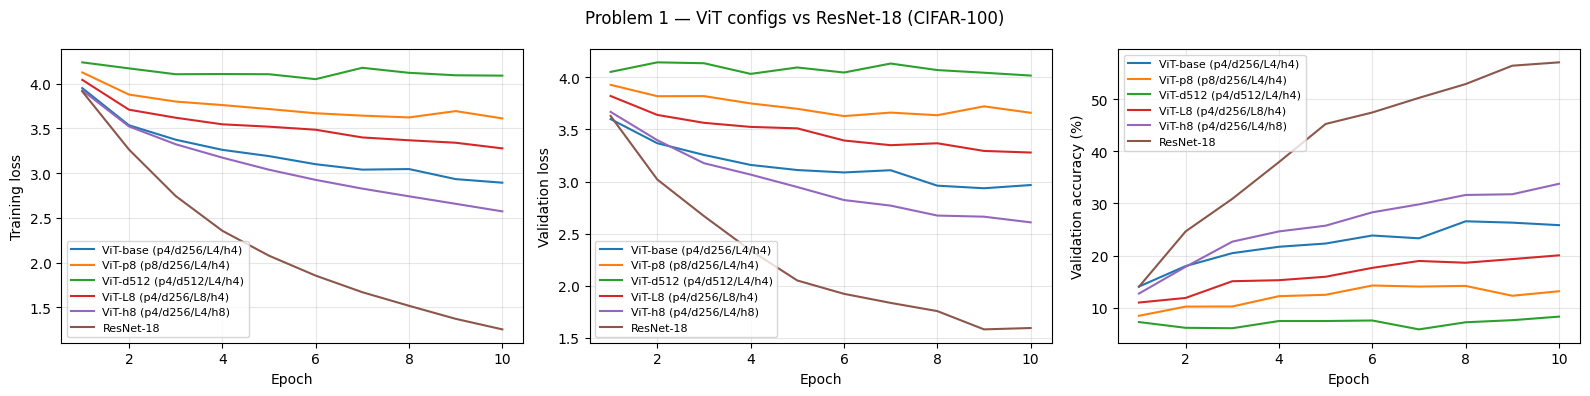

,model,params,trainable,GFLOPs,test acc (%),best val acc (%),s/epoch
0,ViT-base (p4/d256/L4/h4),"3,214,692","3,214,692",0.412,25.83,26.58,10.3
1,ViT-p8 (p8/d256/L4/h4),"3,239,268","3,239,268",0.109,13.13,14.28,9.9
2,ViT-d512 (p4/d512/L4/h4),"12,720,740","12,720,740",1.642,7.97,8.32,19.1
3,ViT-L8 (p4/d256/L8/h4),"6,373,732","6,373,732",0.822,19.92,20.06,15.6
4,ViT-h8 (p4/d256/L4/h8),"3,214,692","3,214,692",0.412,32.08,33.76,10.0
5,ResNet-18,"11,220,132","11,220,132",1.113,57.36,57.02,9.9


In [ ]:
p1_names = list(VIT_CONFIGS.keys()) + ['ResNet-18']
plot_history(p1_names, 'Problem 1 — ViT configs vs ResNet-18 (CIFAR-100)')
results_table(p1_names)

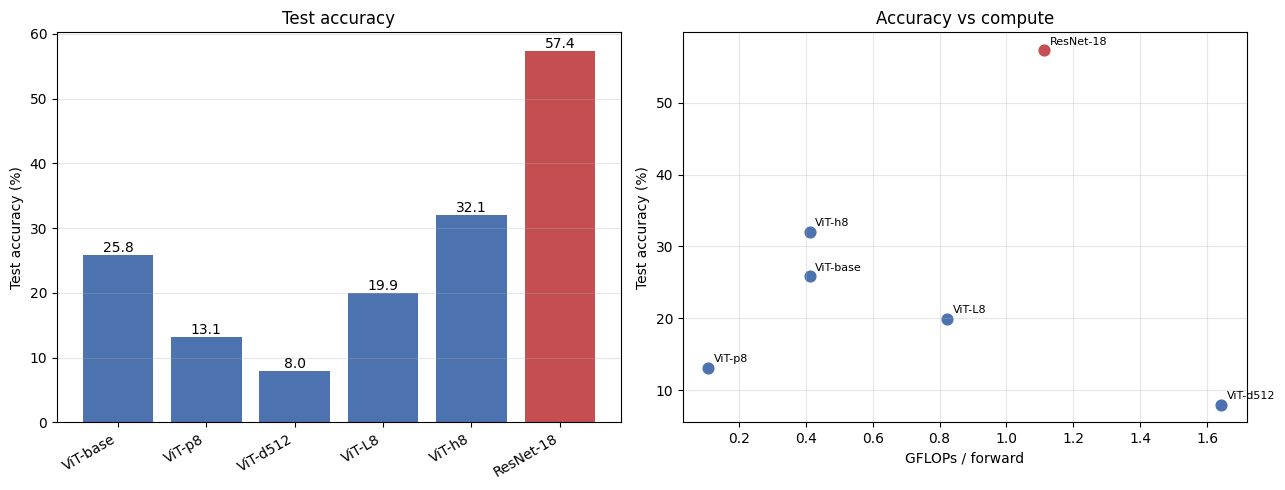

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
accs = [RESULTS[n]['test_acc'] * 100 for n in p1_names]
flps = [RESULTS[n]['gflops'] for n in p1_names]
colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#C44E52']

bars = ax[0].bar(range(len(p1_names)), accs, color=colors)
ax[0].set_xticks(range(len(p1_names)))
ax[0].set_xticklabels([n.split(' ')[0] for n in p1_names], rotation=30, ha='right')
ax[0].bar_label(bars, fmt='%.1f'); ax[0].set_ylabel('Test accuracy (%)')
ax[0].set_title('Test accuracy'); ax[0].grid(axis='y', alpha=0.3)

for n, x, y in zip(p1_names, flps, accs):
    ax[1].scatter(x, y, s=60, color='#C44E52' if n == 'ResNet-18' else '#4C72B0')
    ax[1].annotate(n.split(' ')[0], (x, y), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax[1].set_xlabel('GFLOPs / forward'); ax[1].set_ylabel('Test accuracy (%)')
ax[1].set_title('Accuracy vs compute'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Data — Problem 2 (224x224)
Same 45k/5k/10k split, resized to 224 with ImageNet normalization for the pretrained Swin models. Batch size 32.

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf_224 = T.Compose([
    T.Resize(224),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf_224 = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_aug_224  = torchvision.datasets.CIFAR100(root, train=True,  transform=train_tf_224)
train_eval_224 = torchvision.datasets.CIFAR100(root, train=True,  transform=eval_tf_224)
test_224       = torchvision.datasets.CIFAR100(root, train=False, transform=eval_tf_224)

train_loader_224 = DataLoader(Subset(train_aug_224,  train_idx), batch_size=32,  shuffle=True,  num_workers=2, pin_memory=True)
val_loader_224   = DataLoader(Subset(train_eval_224, val_idx),   batch_size=64,  shuffle=False, num_workers=2, pin_memory=True)
test_loader_224  = DataLoader(test_224, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
P2_LOADERS = (train_loader_224, val_loader_224, test_loader_224)
print(f'train {len(train_idx)} | val {len(val_idx)} | test {len(test_224)} @ 224x224')

train 45000 | val 5000 | test 10000 @ 224x224


---
# Problem 2 — Swin fine-tuning vs from scratch

In [ ]:
from transformers import SwinForImageClassification, SwinConfig

class HFClassifier(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

def build_swin_pretrained(name):
    m = SwinForImageClassification.from_pretrained(name, num_labels=100, ignore_mismatched_sizes=True)
    for p in m.swin.parameters():
        p.requires_grad = False
    return HFClassifier(m)

def build_swin_scratch():
    cfg = SwinConfig(image_size=224, patch_size=4, window_size=7, embed_dim=96,
                     depths=[2, 2, 6, 2], num_heads=[3, 6, 12, 24], num_labels=100)
    return HFClassifier(SwinForImageClassification(cfg))

In [ ]:
train_model(build_swin_pretrained('microsoft/swin-tiny-patch4-window7-224'),
            'Swin-Tiny (pretrained, head only)', P2_LOADERS, epochs=5, lr=2e-5)
train_model(build_swin_pretrained('microsoft/swin-small-patch4-window7-224'),
            'Swin-Small (pretrained, head only)', P2_LOADERS, epochs=5, lr=2e-5)
train_model(build_swin_scratch(),
            'Swin-Tiny (from scratch)', P2_LOADERS, epochs=5, lr=1e-3)

NameError: name 'train_model' is not defined

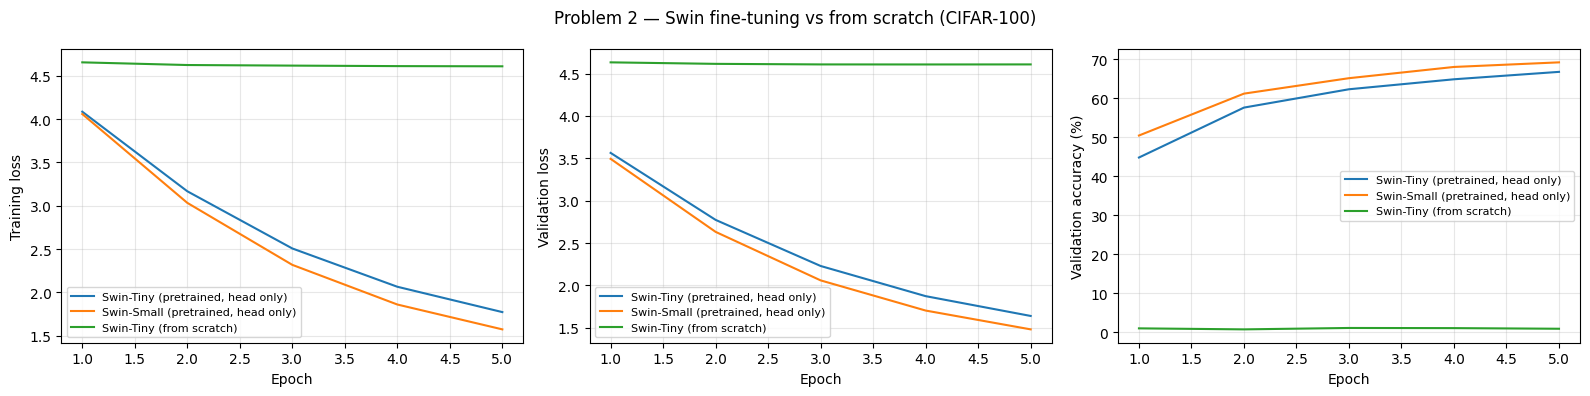

,model,params,trainable,GFLOPs,test acc (%),best val acc (%),s/epoch
0,"Swin-Tiny (pretrained, head only)","27,596,254","76,900",8.737,66.07,66.78,51.7
1,"Swin-Small (pretrained, head only)","48,914,158","76,900",17.078,69.57,69.22,85.2
2,Swin-Tiny (from scratch),"27,596,254","27,596,254",8.737,1.00,1.12,130.0


In [ ]:
p2_names = ['Swin-Tiny (pretrained, head only)', 'Swin-Small (pretrained, head only)',
            'Swin-Tiny (from scratch)', 'Swin-Tiny (from scratch, lr 1e-4)']
plot_history(p2_names, 'Problem 2 — Swin fine-tuning vs from scratch (CIFAR-100)')
results_table(p2_names)

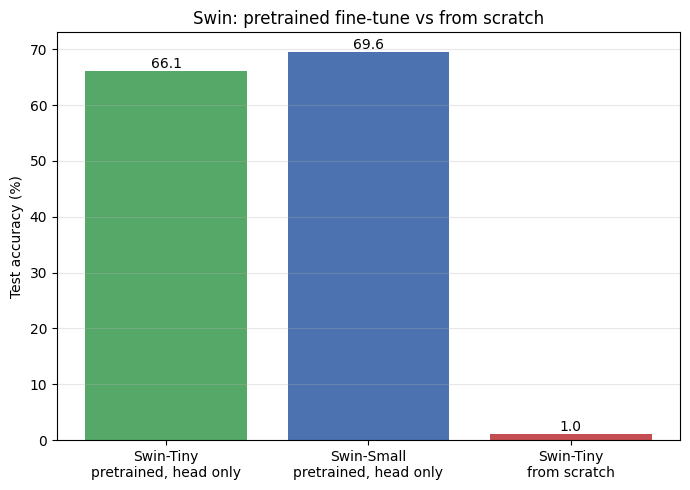

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
accs = [RESULTS[n]['test_acc'] * 100 for n in p2_names]
bars = ax.bar([n.split(' (')[0] + ('\n' + n.split('(')[1][:-1]) for n in p2_names], accs,
              color=['#55A868', '#4C72B0', '#C44E52'])
ax.bar_label(bars, fmt='%.1f'); ax.set_ylabel('Test accuracy (%)')
ax.set_title('Swin: pretrained fine-tune vs from scratch'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()